In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import re
import json
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD CLEAN DATASET
# ============================================================

DATASET_PATH = "../parquet_exports/retrieval_dataset_clean.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 230,088
Columns : 14


,similarity_pk,ticket_pk,source_system,text_source_type,similarity_method,retrieval_text_clean,corpus_quality_score,similarity_confidence,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,repetition_ratio
0,4ceef0c770bdc93599fb1d7131032c69,2013_2,GLPI,synthetic_context,synthetic_context,prio_high urg_critical impact_medium ticket_un...,0.3,0.25,4.0,5.0,3.0,6,97,0.0
1,6cc7ce0f8b7df1ecd0560860283acf40,2013_3,GLPI,synthetic_context,synthetic_context,prio_medium urg_medium impact_medium ticket_un...,0.3,0.25,3.0,3.0,3.0,6,97,0.0
2,23142610733bcac6466bce80d180c346,2013_4,GLPI,synthetic_context,synthetic_context,prio_medium urg_medium impact_medium ticket_un...,0.5,0.45,3.0,3.0,3.0,7,117,0.0
3,10ac3171da0e097808f00c3ad5fb994d,2013_5,GLPI,synthetic_context,synthetic_context,prio_critical urg_critical impact_high ticket_...,0.3,0.25,5.0,5.0,4.0,6,100,0.0
4,49e2a88ee2717c5a044429d4da872925,2013_6,GLPI,synthetic_context,synthetic_context,prio_medium urg_medium impact_medium ticket_un...,0.3,0.25,3.0,3.0,3.0,6,93,0.0


In [3]:
# ============================================================
# CELL 3 — BASIC TEXT FEATURES
# ============================================================

TEXT_COLUMN = "retrieval_text_clean"

# Average word length
df["avg_word_length"] = (
    df[TEXT_COLUMN]
    .apply(
        lambda x: np.mean(
            [len(word) for word in str(x).split()]
        ) if str(x).split() else 0
    )
)

In [4]:
# Unique word ratio
df["unique_word_ratio"] = (
    df[TEXT_COLUMN]
    .apply(
        lambda x: (
            len(set(str(x).split())) / len(str(x).split())
        ) if str(x).split() else 0
    )
)

print("Basic NLP features created.")

df[
    [
        "avg_word_length",
        "unique_word_ratio"
    ]
].head()

Basic NLP features created.


,avg_word_length,unique_word_ratio
0,15.333333,1.0
1,15.333333,1.0
2,15.857143,1.0
3,15.833333,1.0
4,14.666667,1.0


In [5]:
# ============================================================
# CELL 4 — UPPERCASE RATIO
# ============================================================

def uppercase_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    uppercase_chars = sum(1 for c in text if c.isupper())

    return uppercase_chars / len(text)


df["uppercase_ratio"] = (
    df[TEXT_COLUMN]
    .apply(uppercase_ratio)
)

print("uppercase_ratio created.")

uppercase_ratio created.


In [6]:
# ============================================================
# CELL 5 — DIGIT RATIO
# ============================================================

def digit_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    digits = sum(1 for c in text if c.isdigit())

    return digits / len(text)


df["digit_ratio"] = (
    df[TEXT_COLUMN]
    .apply(digit_ratio)
)

print("digit_ratio created.")

digit_ratio created.


In [9]:
# ============================================================
# CELL 6 — SPECIAL CHARACTER RATIO
# ============================================================

def special_char_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    special_chars = len(
        re.findall(r"[^a-zA-Z0-9\s]", text)
    )

    return special_chars / len(text)

df["special_char_ratio"] = (
    df[TEXT_COLUMN]
    .apply(special_char_ratio)
)

print("special_char_ratio created.")

special_char_ratio created.


In [10]:
# ============================================================
# CELL 7 — SOURCE SYSTEM ENCODING
# ============================================================

if "source_system" in df.columns:

    encoder = LabelEncoder()

    df["source_system_encoded"] = (
        encoder.fit_transform(
            df["source_system"].astype(str)
        )
    )

    print("source_system encoded successfully.")

    encoding_mapping = dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    )

    print("\nEncoding Mapping:")
    print(encoding_mapping)


source_system encoded successfully.

Encoding Mapping:
{'GLPI': np.int64(0), 'customer_support_tickets_200k': np.int64(1), 'dataset_tickets_multi_lang': np.int64(2)}


In [11]:
# ============================================================
# CELL 8 — SIMILARITY METHOD ENCODING
# ============================================================

if "similarity_method" in df.columns:

    similarity_encoder = LabelEncoder()

    df["similarity_method_encoded"] = (
        similarity_encoder.fit_transform(
            df["similarity_method"].astype(str)
        )
    )

    print("similarity_method encoded successfully.")

similarity_method encoded successfully.


In [12]:
# ============================================================
# CELL 9 — TEXT COMPLEXITY SCORE
# ============================================================

# heuristic feature

df["text_complexity_score"] = (
    (
        df["avg_word_length"] * 0.4
    )
    +
    (
        df["unique_word_ratio"] * 0.4
    )
    +
    (
        df["text_word_count"] / 100 * 0.2
    )
)

print("text_complexity_score created.")

text_complexity_score created.


In [13]:
# ============================================================
# CELL 10 — RETRIEVAL QUALITY SCORE
# ============================================================

quality_columns = [
    c for c in [
        "corpus_quality_score",
        "similarity_confidence",
        "unique_word_ratio"
    ]
    if c in df.columns
]

df["retrieval_quality_score"] = (
    df[quality_columns]
    .fillna(0)
    .mean(axis=1)
)

print("retrieval_quality_score created.")

retrieval_quality_score created.


In [14]:
# ============================================================
# CELL 11 — BUILD DOCUMENT IDS
# ============================================================

df["document_id"] = (
    "doc_" + df.index.astype(str)
)

print("document_id created.")

document_id created.


In [16]:
# ============================================================
# CELL 12 — BUILD METADATA JSON
# ============================================================

METADATA_COLUMNS = [
    c for c in [
        "ticket_pk",
        "source_system",
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded",
        "similarity_method",
        "corpus_quality_score",
        "similarity_confidence"
    ]
    if c in df.columns
]
def build_metadata(row):

    metadata = {}

    for col in METADATA_COLUMNS:
        metadata[col] = row[col]

    return json.dumps(metadata)


df["metadata_json"] = (
    df.apply(build_metadata, axis=1)
)

print("metadata_json created.")


metadata_json created.


In [17]:
# ============================================================
# CELL 13 — FEATURE DISTRIBUTION SUMMARY
# ============================================================

FEATURE_COLUMNS = [
    "avg_word_length",
    "unique_word_ratio",
    "uppercase_ratio",
    "digit_ratio",
    "special_char_ratio",
    "text_complexity_score",
    "retrieval_quality_score"
]

feature_summary = (
    df[FEATURE_COLUMNS]
    .describe()
)

print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

display(feature_summary)

FEATURE SUMMARY


,avg_word_length,unique_word_ratio,uppercase_ratio,digit_ratio,special_char_ratio,text_complexity_score,retrieval_quality_score
count,230088.000000,230088.000000,230088.0,230088.000000,230088.000000,230088.000000,230088.000000
mean,5.298886,0.536195,0.0,0.000125,0.016310,2.387442,0.809485
std,1.080368,0.120073,0.0,0.001461,0.007135,0.465034,0.043383
min,3.666667,0.454545,0.0,0.000000,0.000000,1.775176,0.516667
25%,4.700000,0.500000,0.0,0.000000,0.013423,2.120000,0.800000
50%,5.153846,0.500000,0.0,0.000000,0.015038,2.298154,0.800000
75%,5.818182,0.500000,0.0,0.000000,0.018018,2.553091,0.800000
max,22.791667,1.000000,0.0,0.064516,0.087500,9.564667,0.966667


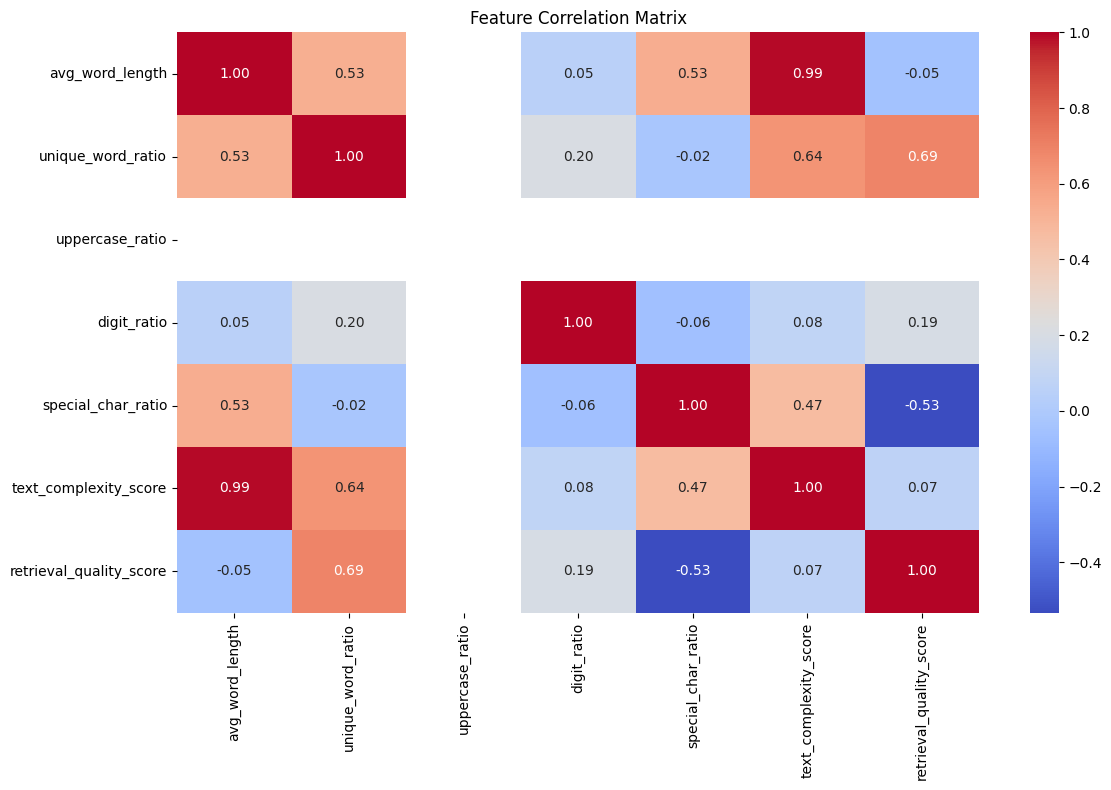

In [18]:
# ============================================================
# CELL 14 — FEATURE CORRELATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

corr = df[FEATURE_COLUMNS].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 15 — TOP COMPLEX TICKETS
# ============================================================

top_complex = (
    df.sort_values(
        by="text_complexity_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP COMPLEX TICKETS")
print("=" * 60)

display(
    top_complex[
        [
            "ticket_pk",
            "text_complexity_score",
            "retrieval_text_clean"
        ]
    ]
)

TOP COMPLEX TICKETS


,ticket_pk,text_complexity_score,retrieval_text_clean
222787,08586bac41d468796d16464948b8d375,9.564667,istcstdintemicrosoftteams synchronisationvonpr...
869,2014_458,7.900000,prio_critical urg_critical impact_critical tic...
722,2014_589,7.876545,prio_medium urg_medium impact_medium ticket_un...
759,2014_587,7.876545,prio_medium urg_medium impact_medium ticket_un...
1022,2014_632,7.803818,prio_medium urg_medium impact_medium ticket_un...
915,2014_504,7.780000,prio_medium urg_medium impact_medium ticket_un...
797,2014_385,7.780000,prio_high urg_critical impact_medium ticket_un...
1429,2014_1046,7.780000,prio_medium urg_medium impact_medium ticket_un...
598,2014_185,7.780000,prio_high urg_critical impact_medium ticket_un...
183,2013_196,7.780000,prio_medium urg_medium impact_medium ticket_un...


In [20]:
# ============================================================
# CELL 16 — TOP RETRIEVAL QUALITY TICKETS
# ============================================================

top_quality = (
    df.sort_values(
        by="retrieval_quality_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP RETRIEVAL QUALITY TICKETS")
print("=" * 60)

display(
    top_quality[
        [
            "ticket_pk",
            "retrieval_quality_score",
            "retrieval_text_clean"
        ]
    ]
)

TOP RETRIEVAL QUALITY TICKETS


,ticket_pk,retrieval_quality_score,retrieval_text_clean
206821,4546df4767697ffe52b7c551a18c33f5,0.966667,privacy violation healthcare provider experien...
226791,c93c9380f14ed275a58c201918944ccd,0.966667,notwendige unterst tzungsanfrage ich habe prob...
221702,15bd2538a94610afc7ab2abba083d900,0.966667,the financial analytics software is not proces...
212401,51fe52a8320a0d850bf5738b2e64c796,0.966667,fehlende funktion bei investitionswerkzeug das...
228141,fbab69a77a51ef855e2e30ca83a869c8,0.966667,noted possible data breach concerning patient ...
211050,cffa7a523b5e2028f75862a319bc3f1b,0.966667,unterst tzung bei investitionsf rderung anfrag...
213500,3c2b09d21eca02df59457e4ebf724f91,0.966667,integrate monday with ibm cloud can you provid...
221731,697f5c770d06acea9688d497df6683b3,0.966667,probleme mit ungenauen datenberichten in der a...
203147,58b884e980694937242ea53945d85723,0.966667,assistance with project coordination kindly su...
216075,ccea60efc811bda1b972046fc0be373d,0.966667,problems with saas project tool experiencing l...


In [21]:
# ============================================================
# CELL 17 — FINAL FEATURE DATASET
# ============================================================

FINAL_FEATURE_COLUMNS = [
    c for c in [
        "document_id",
        "ticket_pk",
        "retrieval_text_clean",
        "metadata_json",
        "source_system_encoded",
        "similarity_method_encoded",
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded",
        "text_word_count",
        "text_char_count",
        "avg_word_length",
        "unique_word_ratio",
        "uppercase_ratio",
        "digit_ratio",
        "special_char_ratio",
        "repetition_ratio",
        "text_complexity_score",
        "retrieval_quality_score",
        "corpus_quality_score",
        "similarity_confidence"
    ]
    if c in df.columns
]

feature_df = (
    df[FINAL_FEATURE_COLUMNS]
    .copy()
)

print("=" * 60)
print("FINAL FEATURE DATASET")
print("=" * 60)

print(f"Rows    : {len(feature_df):,}")
print(f"Columns : {feature_df.shape[1]}")

feature_df.head()

FINAL FEATURE DATASET
Rows    : 230,088
Columns : 21


,document_id,ticket_pk,retrieval_text_clean,metadata_json,source_system_encoded,similarity_method_encoded,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,avg_word_length,unique_word_ratio,uppercase_ratio,digit_ratio,special_char_ratio,repetition_ratio,text_complexity_score,retrieval_quality_score,corpus_quality_score,similarity_confidence
0,doc_0,2013_2,prio_high urg_critical impact_medium ticket_un...,"{""ticket_pk"": ""2013_2"", ""source_system"": ""GLPI...",0,1,4.0,5.0,3.0,6,97,15.333333,1.0,0.0,0.0,0.072165,0.0,6.545333,0.516667,0.3,0.25
1,doc_1,2013_3,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_3"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,6,97,15.333333,1.0,0.0,0.0,0.072165,0.0,6.545333,0.516667,0.3,0.25
2,doc_2,2013_4,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_4"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,7,117,15.857143,1.0,0.0,0.0,0.076923,0.0,6.756857,0.650000,0.5,0.45
3,doc_3,2013_5,prio_critical urg_critical impact_high ticket_...,"{""ticket_pk"": ""2013_5"", ""source_system"": ""GLPI...",0,1,5.0,5.0,4.0,6,100,15.833333,1.0,0.0,0.0,0.080000,0.0,6.745333,0.516667,0.3,0.25
4,doc_4,2013_6,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_6"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,6,93,14.666667,1.0,0.0,0.0,0.075269,0.0,6.278667,0.516667,0.3,0.25


In [22]:
# ============================================================
# CELL 18 — EXPORT FEATURE DATASET
# ============================================================

EXPORT_PATH = "../parquet_exports/feature_engineered_dataset.parquet"

feature_df.to_parquet(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("FEATURE DATASET EXPORTED")
print("=" * 60)

print(f"Export Path:\n{EXPORT_PATH}")

FEATURE DATASET EXPORTED
Export Path:
../parquet_exports/feature_engineered_dataset.parquet


In [23]:
# ============================================================
# CELL 19 — EXPORT FEATURE SAMPLE
# ============================================================

SAMPLE_EXPORT = "../evaluation/feature_dataset_sample.csv"

feature_df.head(100).to_csv(
    SAMPLE_EXPORT,
    index=False
)

print(f"Sample exported to:\n{SAMPLE_EXPORT}")

Sample exported to:
../evaluation/feature_dataset_sample.csv


In [24]:
# ============================================================
# CELL 20 — FINAL FEATURE HEALTH REPORT
# ============================================================

print("=" * 60)
print("FINAL FEATURE HEALTH REPORT")
print("=" * 60)

print(f"Total Rows                 : {len(feature_df):,}")
print(f"Total Features             : {feature_df.shape[1]}")
print(f"Average Complexity Score   : {feature_df['text_complexity_score'].mean():.4f}")
print(f"Average Retrieval Quality  : {feature_df['retrieval_quality_score'].mean():.4f}")

if "source_system_encoded" in feature_df.columns:
    print(f"Unique Source Systems      : {feature_df['source_system_encoded'].nunique()}")

if "similarity_method_encoded" in feature_df.columns:
    print(f"Unique Similarity Methods  : {feature_df['similarity_method_encoded'].nunique()}")

FINAL FEATURE HEALTH REPORT
Total Rows                 : 230,088
Total Features             : 21
Average Complexity Score   : 2.3874
Average Retrieval Quality  : 0.8095
Unique Source Systems      : 3
Unique Similarity Methods  : 2
